<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [4]:
!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl datasets langchain-community ragatouille umap-learn

In [5]:
import sys
from types import ModuleType

# Попытка импорта из нового официального места в LangChain 0.3+
try:
    from langchain_core.documents.compressor import BaseDocumentCompressor
except ImportError:
    try:
        from langchain_core.retrievers import BaseDocumentCompressor
    except ImportError:
        print("всё плохо...")
        # Если совсем всё плохо, создаем ПУСТОЙ класс-заглушку, 
        # чтобы ragatouille просто импортировалась (но reranking может не работать)
        class BaseDocumentCompressor: pass

# Создаем структуру для RAGatouille
comp_mod = ModuleType("langchain.retrievers.document_compressors.base")
comp_mod.BaseDocumentCompressor = BaseDocumentCompressor
sys.modules["langchain.retrievers.document_compressors.base"] = comp_mod
sys.modules["langchain.retrievers.document_compressors"] = comp_mod
sys.modules["langchain.retrievers"] = ModuleType("langchain.retrievers")

print("Костыли установлены успешно! Пробуем импорт...")

Костыли установлены успешно! Пробуем импорт...


In [6]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
# from langchain.docstore.document import Document as LangchainDocument
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
# from langchain.vectorstores import FAISS
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

/Users/elenadolgunicheva/Desktop/DLS/.rag_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/r4/plh8rcws7psc_vyl2ny_fdb80000gn/T/ipykernel_34556/1682258526.py:19: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


## Загрузка данных (4 балла)

In [13]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=20423746-36a2-4af3-bcf8-b529caf0b75b
To: /Users/elenadolgunicheva/Desktop/DLS/file.csv
100%|██████████| 672M/672M [01:48<00:00, 6.16MB/s] 


In [14]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [15]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [16]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

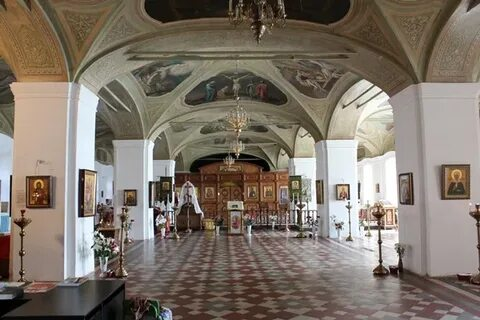

In [17]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [20]:
print(data[['City', 'Name', 'description','WikiData']].isna().sum())

City           0
Name           0
description    0
WikiData       0
dtype: int64


In [29]:
# your code here
print(f"Data  before cleaning: {len(data)}")
data = data.dropna(subset=['description'])

# Double check the result
clean_samples = data.groupby(['City', 'Name']).sample(n=1, random_state=42)

print(f"Data remaining after cleaning : {len(clean_samples)}")

Data  before cleaning: 12078
Data remaining after cleaning : 320


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Готовим корпус текстов
corpus = clean_samples['description'].astype(str).tolist()

# 2. Настраиваем TF-IDF
# max_df=0.8 — игнорируем слова, которые есть в 80% документов (слишком общие)
# min_df=2 — игнорируем слова, которые встретились только 1 раз (опечатки)
vectorizer = TfidfVectorizer(max_df=0.8, min_df=2)
tfidf_matrix = vectorizer.fit_transform(corpus)

# 3. Вытаскиваем слова и их средние веса
words = vectorizer.get_feature_names_out()
weights = tfidf_matrix.mean(axis=0).getA1()

# 4. Создаем таблицу результатов
tfidf_res = pd.DataFrame({'word': words, 'weight': weights}).sort_values(by='weight', ascending=False)

# Посмотрим на топ-20 самых характерных слов
print("Топ слов по весу TF-IDF (самые информативные):")
print(tfidf_res.head(20))

# Посмотрим на самые "слабые" слова (возможно, шум)
print("\nСлова с самым низким весом:")
print(tfidf_res.tail(10))

Топ слов по весу TF-IDF (самые информативные):
               word    weight
32    екатеринбурге  0.106517
123       ярославле  0.082370
27              дом  0.069516
68            музей  0.058815
115            храм  0.055794
37           здание  0.051212
84         памятник  0.050102
118         церковь  0.048868
88     православный  0.045456
124       ярославль  0.034975
66        монастырь  0.034273
5             башня  0.026476
76           нижнем  0.026460
81        новгороде  0.026460
85             парк  0.026412
111         усадьба  0.021875
51           кремля  0.021710
72   нижегородского  0.021710
79         новгород  0.021211
77           нижний  0.021211

Слова с самым низким весом:
              word    weight
98        символов  0.002466
93   расположенный  0.001957
29    единственный  0.001957
26     добролюбова  0.001957
78         николая  0.001957
65            мире  0.001957
61   литературного  0.001957
54         критика  0.001957
2   александровича  0.001957
86  

In [33]:
# 1. Заменяем все виды пустоты на честный NaN
data['en_txt'] = data['en_txt'].replace(['', ' ', 'None', 'NaN'], np.nan)
data['WikiData'] = data['WikiData'].replace(['', ' ', 'None', 'NaN'], np.nan)
print(data[['en_txt','WikiData']].isna().sum())

en_txt      0
WikiData    0
dtype: int64


In [36]:
# Создаем колонку с длиной текста
data['text_len'] = data['en_txt'].astype(str).str.len()

# Группируем по WikiData и берем индекс строки с самым длинным текстом
best_indices = data.groupby('WikiData')['text_len'].idxmax()
clean_samples = data.loc[best_indices].copy()

print(f"Количество уникальных объектов: {len(clean_samples)}")
print(f"Средняя длина описания (в символах): {clean_samples['en_txt'].str.len().mean():.1f}")

Количество уникальных объектов: 296
Средняя длина описания (в символах): 73.9


In [37]:
avg_words = clean_samples['en_txt'].str.split().str.len().mean()
print(f"Среднее количество слов: {avg_words:.1f}")

Среднее количество слов: 15.1


In [38]:
# Находим самое короткое и длинное описание в исходных данных (до склеивания)
shortest_raw_idx = data['en_txt'].str.len().idxmin()
longest_raw_idx = data['en_txt'].str.len().idxmax()

print("--- САМОЕ КОРОТКОЕ (ДО СКЛЕИВАНИЯ) ---")
print(f"Объект: {data.loc[shortest_raw_idx, 'Name']}")
print(f"Текст: '{data.loc[shortest_raw_idx, 'en_txt']}'")
print(f"Длина: {len(str(data.loc[shortest_raw_idx, 'en_txt']))} симв.")

print("\n--- САМОЕ ДЛИННОЕ (ДО СКЛЕИВАНИЯ) ---")
print(f"Объект: {data.loc[longest_raw_idx, 'Name']}")
print(f"Текст: '{data.loc[longest_raw_idx, 'en_txt']}'")
print(f"Длина: {len(str(data.loc[longest_raw_idx, 'en_txt']))} симв.")

--- САМОЕ КОРОТКОЕ (ДО СКЛЕИВАНИЯ) ---
Объект: Ярославский дворец молодёжи
Текст: 'прррмомоннннннннннн'
Длина: 19 симв.

--- САМОЕ ДЛИННОЕ (ДО СКЛЕИВАНИЯ) ---
Объект: №18 Фотографический музей «Дом Метенкова»
Текст: 'pedestrians crossing a street in front of a yellow building with a sign that says gopeta russian'
Длина: 96 симв.


In [39]:
import re

def is_clean_english(text):
    # 1. Проверяем, что в тексте только латиница, цифры и базовые знаки (без кириллицы)
    if bool(re.search('[а-яА-Я]', text)):
        return False
    
    # 2. Проверяем на "прррмомоннннн" (если одна и та же буква повторяется более 3 раз подряд)
    if bool(re.search(r'(.)\1{3,}', text)):
        return False
        
    return True

# Применяем фильтры
# Оставляем: длина > 25 символов И нет кириллицы И нет повторов букв
data_clean_lat = data[
    (data['en_txt'].str.len() > 25) & 
    (data['en_txt'].apply(is_clean_english))
].copy()

# Теперь выбираем самое длинное из оставшегося "чистого"
best_indices = data_clean_lat.groupby('WikiData')['text_len'].idxmax()
clean_samples_final = data_clean_lat.loc[best_indices].copy()

print(f"Осталось объектов после жесткой фильтрации: {len(clean_samples_final)}")

Осталось объектов после жесткой фильтрации: 296


In [40]:
# Находим самое короткое и длинное описание в данных осле жесткой фильтрации
shortest_raw_idx = clean_samples_final['en_txt'].str.len().idxmin()
longest_raw_idx = clean_samples_final['en_txt'].str.len().idxmax()

print("--- САМОЕ КОРОТКОЕ (после жесткой фильтрации) ---")
print(f"Объект: {clean_samples_final.loc[shortest_raw_idx, 'Name']}")
print(f"Текст: '{clean_samples_final.loc[shortest_raw_idx, 'en_txt']}'")
print(f"Длина: {len(str(clean_samples_final.loc[shortest_raw_idx, 'en_txt']))} симв.")

print("\n--- САМОЕ ДЛИННОЕ (после жесткой фильтрации) ---")
print(f"Объект: {clean_samples_final.loc[longest_raw_idx, 'Name']}")
print(f"Текст: '{clean_samples_final.loc[longest_raw_idx, 'en_txt']}'")
print(f"Длина: {len(str(clean_samples_final.loc[longest_raw_idx, 'en_txt']))} симв.")

--- САМОЕ КОРОТКОЕ (после жесткой фильтрации) ---
Объект: Успенский Княгинин монастырь
Текст: 'arafed white building with a green roof and a white fence'
Длина: 57 симв.

--- САМОЕ ДЛИННОЕ (после жесткой фильтрации) ---
Объект: Уральский государственный университет имени А. М. Горького
Текст: 'there is a large building with a sign on it that says the national museum of the american indian'
Длина: 96 симв.


In [41]:
avg_words = clean_samples_final['en_txt'].str.split().str.len().mean()
print(f"Среднее количество слов: {avg_words:.1f}")

Среднее количество слов: 15.1


In [42]:
# 1. Группируем по WikiData (наш уникальный ключ) 
# и склеиваем все уникальные описания, прошедшие фильтр
clean_samples_combined = data_clean_lat.groupby('WikiData').agg({
    'City': 'first',
    'Name': 'first',
    'en_txt': lambda x: " ".join(dict.fromkeys(x)), # удаляем дубликаты и склеиваем
    'image': 'first' # картинку для метаданных берем одну
}).reset_index()

# 2. Считаем новую длину
avg_words_combined = clean_samples_combined['en_txt'].str.split().str.len().mean()
print(f"Объектов в базе: {len(clean_samples_combined)}")
print(f"Новое среднее количество слов после склеивания: {avg_words_combined:.1f}")

# 3. Посмотрим на самого длинного "гиганта" теперь
longest_idx = clean_samples_combined['en_txt'].str.len().idxmax()
print("\n--- ПРИМЕР СКЛЕЕННОГО ОПИСАНИЯ ---")
print(f"Объект: {clean_samples_combined.loc[longest_idx, 'Name']}")
print(f"Текст: {clean_samples_combined.loc[longest_idx, 'en_txt']}")

Объектов в базе: 296
Новое среднее количество слов после склеивания: 421.1

--- ПРИМЕР СКЛЕЕННОГО ОПИСАНИЯ ---
Объект: Колокольня Никитского прихода
Текст: cars are parked in front of a church with a golden dome trees are in the foreground and a building in the background there is a white building with a golden dome on top arafed view of a street with a church steeple in the background arafed church with a golden dome on top of it arafed view of a church with a golden dome on top there is a white building with a gold dome on top arafed brick tower with a cross on top of it arafed brick tower with a clock on top of it trees are in front of a building with a clock tower arafed building with a golden dome on top of it arafed brick building with a clock tower and a bell tower arafed photo of a street with a church and a church an old photo of a church with a steeple and a steeple on the roof arafed tower with a clock on top of it in a field there is a white building with a clock on the top

In [43]:
clean_samples_combined.head()

,WikiData,City,Name,en_txt,image
0,Q100270892,Нижний Новгород,Нижегородский Кремль,arafed view of a castle on a hill with a river...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
1,Q100701435,Нижний Новгород,Гарнизонная казарма,arafed view of a large yellow building with a ...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
2,Q100882660,Нижний Новгород,Губернаторский сад,there is a large yellow building with a clock ...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
3,Q104554178,Ярославль,Церковь Николы в Меленках,arafed church with green domes in a snowy area...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
4,Q104776528,Нижний Новгород,Церковь в честь Преображения Господня,arafed church with green domes and a steeple o...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...


In [ ]:
# 1. Подготовка финальных документов
embeddings_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
final_docs = []
for _, row in clean_samples_combined.iterrows():
    # Соединяем метаданные и текст
    content = f"Name: {row['Name']}. City: {row['City']}. Description: {row['en_txt']}"
    metadata = {
        "name": row['Name'],
        "city": row['City'],
        "wikidata": row['WikiData'],
        "image": row['image']
    }
    final_docs.append(LangchainDocument(page_content=content, metadata=metadata))

# 2. Создание индекса 
vector_db = FAISS.from_documents(final_docs, embeddings_model)

# 3. Сохранение
vector_db.save_local("tourist_rag_index")
print(f"База на {len(final_docs)} объектов готова к работе!")

/var/folders/r4/plh8rcws7psc_vyl2ny_fdb80000gn/T/ipykernel_34556/1292385963.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: d2afe374-5e22-4af1-9873-126d3ecbd3b1)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer')), '(Request ID: 91962b35-e667-411d-8688-54565a58de0f)')' t

База на 296 объектов готова к работе!


In [47]:
results = vector_db.similarity_search("A white church with golden domes", k=1)


In [46]:
print(results[0])

page_content='Name: Крестовоздвиженская церковь (Екатеринбург). City: Екатеринбург. Description: yellow church with a golden dome on a cloudy day araffature of a church with a golden dome in a city yellow church with a golden dome on a sunny day arafed church with a golden dome and a steeple on a street corner snowy landscape of a church with a tree in front of it arafed view of a yellow and white church with a red roof an old photo of a church with a steeple and a clock tower cars parked on a snowy street in front of a yellow church arafed view of a church with a large altar and a man in the background yellow building with a steeple and a cross on top arafed yellow church with a golden dome in a city there is a black and white photo of a church with a clock tower yellow church with a golden dome and a steeple on a street corner yellow building with a golden dome and a horse drawn carriage arafed church with a steeple and a clock tower buildings in the background of a city with a steep

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [ ]:
!pip install "transformers<5.0.0"

In [48]:
from ragatouille import RAGPretrainedModel
reranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

/Users/elenadolgunicheva/Desktop/DLS/.rag_venv/lib/python3.12/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()
/Users/elenadolgunicheva/Desktop/DLS/.rag_venv/lib/python3.12/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


In [49]:
def get_reranked_docs(query, k_initial=10, k_final=3):
    # 1. Сначала берем "с запасом" из FAISS (например, 10 штук)
    initial_docs = vector_db.similarity_search(query, k=k_initial)
    
    # 2. Вытаскиваем только текст для реранкера
    texts = [doc.page_content for doc in initial_docs]
    
    # 3. Ragatouille переставляет их в порядке реальной релевантности
    # Он вернет список с индексами (result_index)
    results = reranker.rerank(query=query, documents=texts, k=k_final)
    
    # 4. Собираем отранжированные документы обратно
    ranked_docs = [initial_docs[res['result_index']] for res in results]
    
    return ranked_docs

In [53]:
# Проверяем работу
query = "Расскажи про интересные места в Москве"
best_docs = get_reranked_docs(query)

for i, doc in enumerate(best_docs):
    print(f"Позиция {i+1}: {doc.metadata['name']}")

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]

Позиция 1: Музей истории города Ярославля
Позиция 2: Свердловское художественное училище им. И. Д. Шадра
Позиция 3: №18 Фотографический музей «Дом Метенкова»


Получилась ерунда. Проблема в том, что в нашем content мешаются русские и английские слова. Поэтому сейчас я переведу названия городов на английский, 'Name' вообше выкину из content, а русские 'Name' и 'City' перенесу в metadata. Вопрос также будет на английском.

In [54]:
unique_cities = clean_samples_combined['City'].unique().tolist()
print(unique_cities)

['Нижний Новгород', 'Ярославль', 'Екатеринбург', 'Владимир']


In [55]:
city_map_en = {
    "Нижний Новгород": "Nizhny Novgorod",
    "Ярославль": "Yaroslavl",
    "Екатеринбург": "Yekaterinburg",
    "Владимир": "Vladimir"
}

In [56]:
final_docs = []
for _, row in clean_samples_combined.iterrows():
    city_en = city_map_en.get(row['City'], "Unknown")
    
    # CONTENT: Pure English for the Vector Model
    # We use only City and the combined BLIP descriptions
    content = f"City: {city_en}. Description: {row['en_txt']}"
    
    # METADATA: Russian for the UI/Final Answer
    metadata = {
        "name": row['Name'],
        "city": row['City'],
        "wikidata": row['WikiData'],
        "image": row['image']
    }
    final_docs.append(LangchainDocument(page_content=content, metadata=metadata))

# Re-initialize FAISS
vector_db = FAISS.from_documents(final_docs, embeddings_model)
vector_db.save_local("tourist_rag_index_final")

In [58]:
# Search for a specific visual feature in a specific city
query = "A white stone church in Moscow"
best_docs = get_reranked_docs(query) # Using your Ragatouille function

for i, doc in enumerate(best_docs):
    print(f"Rank {i+1}: {doc.metadata['name']} ({doc.metadata['city']})")

100%|██████████| 1/1 [00:00<00:00,  1.05it/s]

Rank 1: Собор Архангела Михаила (Нижний Новгород)
Rank 2: Печёрский Вознесенский монастырь (Нижний Новгород)
Rank 3: Церковь в честь Преображения Господня (Нижний Новгород)


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

/Users/elenadolgunicheva/Desktop/DLS/.rag_venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


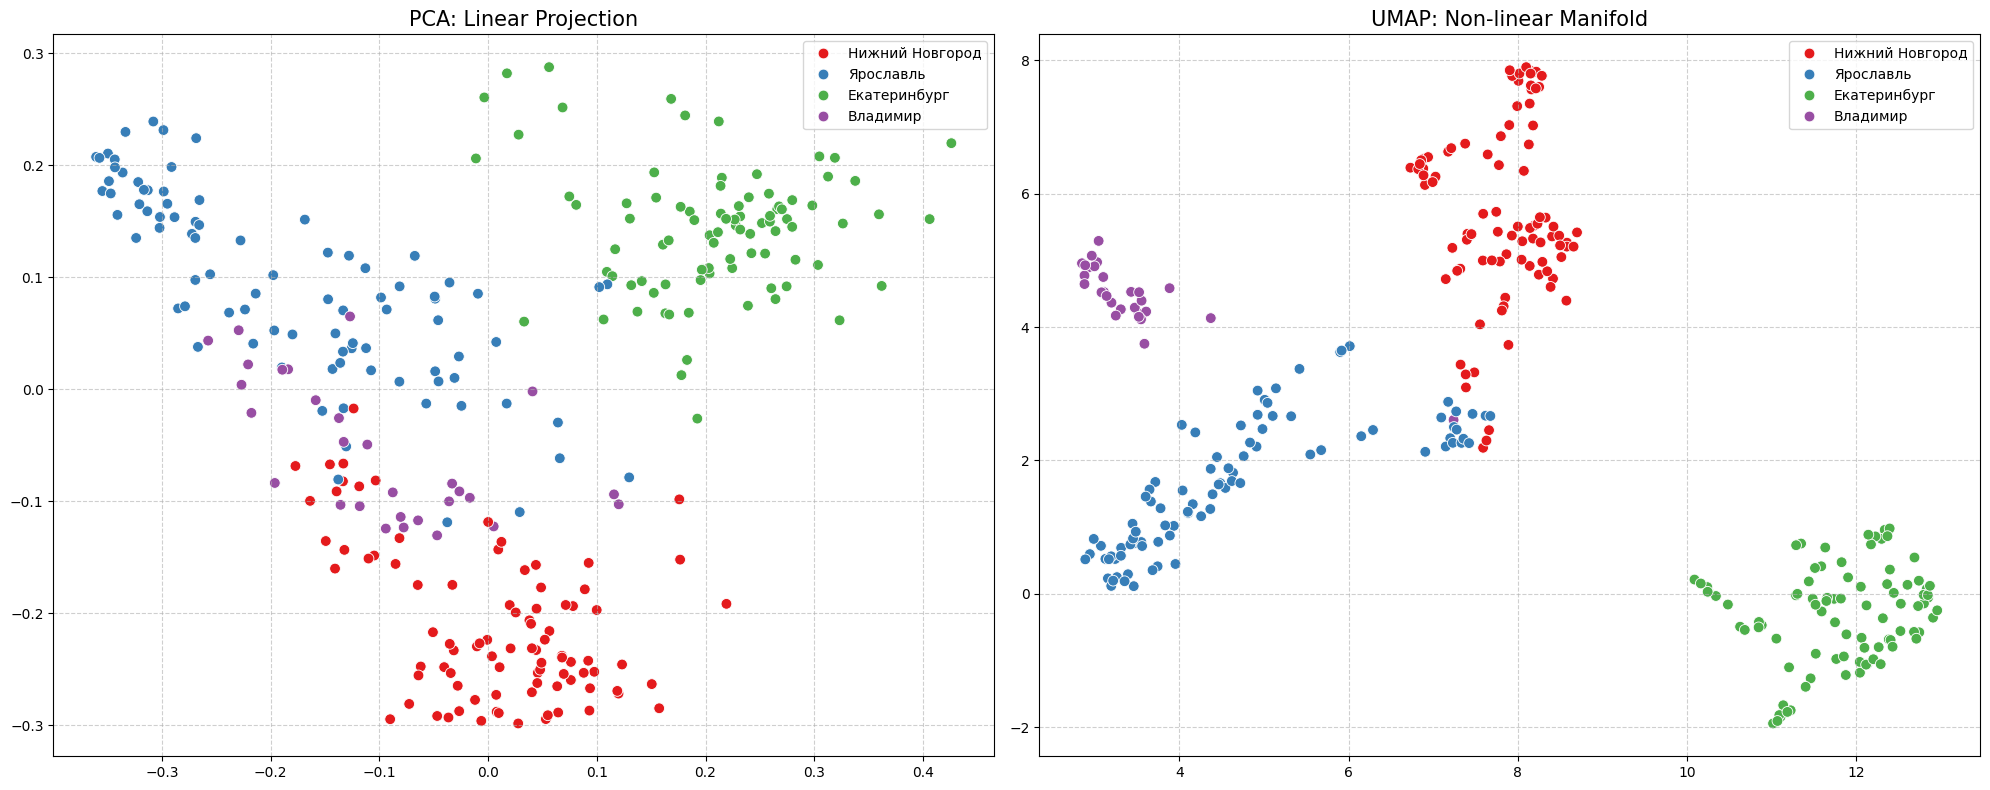

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap.umap_ as umap

# 1. Extract embeddings and cities from your FAISS index
# We reconstruct all vectors from the index
embeddings = np.array([
    vector_db.index.reconstruct(i) 
    for i in range(vector_db.index.ntotal)
])

# Extract cities for the legend
metadatas = [
    vector_db.docstore.search(vector_db.index_to_docstore_id[i]).metadata 
    for i in range(len(embeddings))
]
cities = [m['city'] for m in metadatas]

# 2. PCA (Independent)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(embeddings)

# 3. UMAP (Independent)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(embeddings)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# PCA Plot
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=cities, ax=ax1, palette="Set1", s=60)
ax1.set_title("PCA: Linear Projection", fontsize=15)
ax1.grid(True, linestyle='--', alpha=0.6)

# UMAP Plot
sns.scatterplot(x=umap_results[:,0], y=umap_results[:,1], hue=cities, ax=ax2, palette="Set1", s=60)
ax2.set_title("UMAP: Non-linear Manifold", fontsize=15)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
#your code here

Визуализация подтверждает высокое качество подготовленной векторной базы. Метод PCA выделил Екатеринбург как наиболее семантически удаленный регион (что логично). Так же интересно выглядит перетекание Нижнего Новгорода в Ярославль через Владимир. Метод UMAP продемонстрировал четкую кластеризацию по городам, что говорит о том, что эмбеддинги успешно уловили локальную специфику объектов. Это гарантирует высокую точность поиска в RAG-системе при фильтрации по городам

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

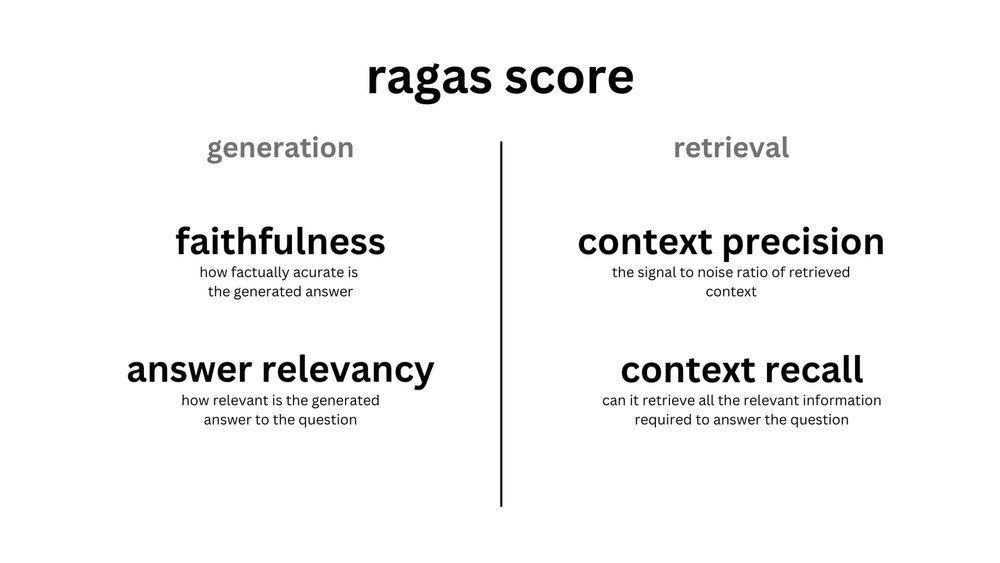

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [85]:
def data_preprocess(df, n=100):
    samples = df.sample(n=min(n, len(df)), random_state=42)
    
    # Тот самый словарь, что мы делали раньше
    city_map_en = {
        "Нижний Новгород": "Nizhny Novgorod",
        "Ярославль": "Yaroslavl",
        "Екатеринбург": "Yekaterinburg",
        "Владимир": "Vladimir"
    }
    
    eval_data = []
    for _, row in samples.iterrows():
        city_en = city_map_en.get(row['City'], "Russia")
        #плохая идея - винегрет из русского и английского
        # eval_data.append({
        #     "question": f"What does {row['Name']} in {row['City']} look like?", # Генерируем вопрос
        #     "ground_truths": [row['en_txt']], # Эталонное описание (то что есть в базе)
        #     "answer": row['en_txt'],          # Ответ модели (в идеале он должен совпасть с эталоном)
        #     "contexts": [row['en_txt']]       # Контекст, который мы "нашли"
        # })
        
        # Генерируем ЧИСТЫЙ английский вопрос
        # (Название оставляем как есть, но в контексте английской фразы)
        question = f"Can you provide a visual description of '{row['Name']}' located in {city_en}?"
        
        eval_data.append({
            "question": question,
            "ground_truths": [row['en_txt']], 
            "answer": row['en_txt'],          
            "contexts": [row['en_txt']]       
        })
    
    return pd.DataFrame(eval_data)

In [82]:
eval_dataset_ru_citynames = data_preprocess(clean_samples_combined, n=100)

In [83]:
eval_dataset_ru_citynames.head()

,question,ground_truths,answer,contexts
0,What does Дом Виноградовых in Нижний Новгород ...,[there is a large building with a lot of windo...,there is a large building with a lot of window...,[there is a large building with a lot of windo...
1,What does Литературная жизнь Урала XX века in ...,[arafed building with a metal roof and a metal...,arafed building with a metal roof and a metal ...,[arafed building with a metal roof and a metal...
2,What does Площадь 1905 года in Екатеринбург lo...,[soldiers stand in formation in front of a lar...,soldiers stand in formation in front of a larg...,[soldiers stand in formation in front of a lar...
3,What does Cerkiew św. Dymitra Sołuńskiego w Ja...,[snowy landscape of a church with a green dome...,snowy landscape of a church with a green dome ...,[snowy landscape of a church with a green dome...
4,What does Князь-Владимирская церковь in Владим...,[there is a large yellow building with a green...,there is a large yellow building with a green ...,[there is a large yellow building with a green...


In [78]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
def answer_relevancy(dataset, model):
    scores = []
    
    for index, row in dataset.iterrows():
        # Используем .embed_query() вместо .encode()
        q_embedding = np.array(model.embed_query(row['question'])).reshape(1, -1)
        a_embedding = np.array(model.embed_query(row['answer'])).reshape(1, -1)
        
        # Считаем сходство
        score = cosine_similarity(q_embedding, a_embedding)[0][0]
        scores.append(score)
    
    return np.mean(scores)




In [ ]:
# --- ЗАПУСК ---

# Подготавливаем данные (100 штук)
eval_dataset = data_preprocess(clean_samples_combined, n=100)

# Считаем метрику
# Передаем наш набор и модель embeddings_model (all-mpnet-base-v2)
final_score = answer_relevancy(eval_dataset, embeddings_model)

print(f"Итоговая релевантность (Answer Relevancy): {final_score:.4f}")

Итоговая релевантность (Answer Relevancy): 0.4124


In [ ]:
# Вопрос на английском!!!
def test_my_tourist_rag(user_query_en, k_initial=10, k_final=3):
    print(f"🔎 Запрос пользователя: {user_query_en}")
    
    # 1. Поиск в FAISS
    initial_docs = vector_db.similarity_search(query_en, k=k_initial)
    
    # 3. Реранжирование через Ragatouille
    texts = [doc.page_content for doc in initial_docs]
    # Важно: Ragatouille может ругаться, если k_final > k_initial
    results = reranker.rerank(query=query_en, documents=texts, k=k_final)
    
    print(f"✅ Найдено наиболее подходящих объектов: {len(results)}\n")
    print("-" * 50)
    
    for i, res in enumerate(results):
        doc = initial_docs[res['result_index']]
        name = doc.metadata.get('name', 'Unknown')
        city = doc.metadata.get('city', 'Unknown')
        
        print(f"📍 МЕСТО №{i+1}: {name}")
        print(f"   Город: {city}")
        print(f"   Скор реранкера: {res['score']:.4f}")
        # Выводим кусочек нашего "супер-описания" из 400 слов
        short_desc = doc.page_content.split('Description: ')[1][:150]
        print(f"   Описание: {short_desc}...")
        print("-" * 50)


In [89]:
# Тест 1: Поиск по визуальному признаку (Золотые купола)
test_my_tourist_rag("white church with golden domes in Yaroslavl")

# Тест 2: Поиск по типу объекта (Музей в Екатеринбурге)
test_my_tourist_rag("modern art museum in Yekaterinburg")

🔎 Запрос пользователя: white church with golden domes in Yaroslavl


/Users/elenadolgunicheva/Desktop/DLS/.rag_venv/lib/python3.12/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
/Users/elenadolgunicheva/Desktop/DLS/.rag_venv/lib/python3.12/site-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
100%|██████████| 1/1 [00:00<00:00,  1.03it/s]


✅ Найдено наиболее подходящих объектов: 3

--------------------------------------------------
📍 МЕСТО №1: Успенский собор
   Город: Ярославль
   Скор реранкера: 26.2385
   Описание: arafed view of a large white building with gold domes arafed view of a white building with gold domes in a park arafed view of a large white building ...
--------------------------------------------------
📍 МЕСТО №2: храм Ярославской иконы Божией Матери
   Город: Ярославль
   Скор реранкера: 26.2231
   Описание: arafed church with a steeple and a golden dome arafed white church with blue domes and a blue roof arafed white building with green domes and a red do...
--------------------------------------------------
📍 МЕСТО №3: Николо-Сковородский монастырь
   Город: Ярославль
   Скор реранкера: 26.0238
   Описание: arafed church with green domes and a cross on top arafed church with green domes in a snowy area arafed view of a large white building with green dome...
-------------------------------------------

100%|██████████| 1/1 [00:00<00:00,  1.02it/s]

✅ Найдено наиболее подходящих объектов: 3

--------------------------------------------------
📍 МЕСТО №1: Художественный Музей Эрнста Неизвестного
   Город: Екатеринбург
   Скор реранкера: 21.5050
   Описание: there is a man walking up a set of stairs in front of a building there are three sculptures on display in a museum with a glass case arafed image of a...
--------------------------------------------------
📍 МЕСТО №2: Музей изобразительных искусств
   Город: Екатеринбург
   Скор реранкера: 21.1964
   Описание: arafed building with a large glass window and a sign on the front people looking at art in a museum with paintings on display there is a building with...
--------------------------------------------------
📍 МЕСТО №3: Свердловское художественное училище им. И. Д. Шадра
   Город: Екатеринбург
   Скор реранкера: 19.8121
   Описание: there is a bus stop on the side of the road arafed view of a large building with a steeple on top cars are driving down a city street with tall bui

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# your code here